In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

seed= 42

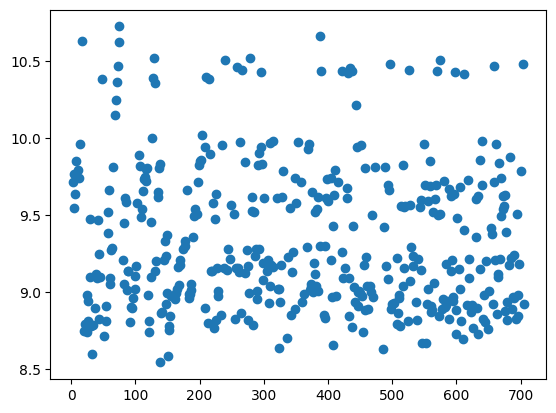

In [26]:
from sklearn.model_selection import train_test_split

train_df= pd.read_csv('train.csv')
test_df= pd.read_csv('test.csv')

X= train_df.drop(columns=['CarID', 'price'])
y= np.log1p(train_df['price'])

X_train, X_eval, y_train, y_eval= train_test_split(X, y, train_size=0.8, random_state= seed)

X_test= test_df.drop(columns=['CarID'])

cat_cols= X.select_dtypes(include=['object', 'string']).columns.to_list()

plt.scatter(train_df['CarID'], y)
plt.show()


In [27]:
# Subtask 1

answer1= pd.DataFrame([{
    'subtaskID': 1,
    'datapointID': 1,
    'answer': train_df['enginetype'].value_counts().index[0]
}])

answer1.head()

,subtaskID,datapointID,answer
0,1,1,ohc


In [28]:
# Subtask 2

answer2= pd.DataFrame([{
    'subtaskID': 2,
    'datapointID': 1,
    'answer': round(train_df[train_df['fueltype']== 'gas']['price'].mean(), 2)
}])

answer2.head()

,subtaskID,datapointID,answer
0,2,1,12728.06


In [29]:
# Subtask 3

from catboost import CatBoostRegressor

for col in cat_cols:
    X_train[col]= X_train[col].astype(str).fillna('missing')
    X_eval[col]= X_eval[col].astype(str).fillna('missing')
    X_test[col]= X_test[col].astype(str).fillna('missing')

model= CatBoostRegressor(
    iterations=3000,
    learning_rate=0.03,
    depth=6,
    cat_features=cat_cols,
    early_stopping_rounds=200,
    random_state= seed
)

model.fit(
    X_train, y_train,
    eval_set=[(X_eval, y_eval)],
    verbose=200
)

predictions= np.expm1(model.predict(X_test))

answer3= pd.DataFrame([{
    'subtaskID': 3,
    'datapointID': id_,
    'answer': pred
} for id_, pred in zip(test_df['CarID'], predictions)])

answer3.head()

0:	learn: 0.4606041	test: 0.4991867	best: 0.4991867 (0)	total: 70.4ms	remaining: 3m 31s
200:	learn: 0.0754113	test: 0.1205106	best: 0.1205106 (200)	total: 2.94s	remaining: 41s
400:	learn: 0.0526962	test: 0.1085822	best: 0.1085822 (400)	total: 5.76s	remaining: 37.3s
600:	learn: 0.0408915	test: 0.1041813	best: 0.1041139 (587)	total: 9.12s	remaining: 36.4s
800:	learn: 0.0336577	test: 0.1026172	best: 0.1025558 (790)	total: 12.3s	remaining: 33.9s
1000:	learn: 0.0290901	test: 0.1012836	best: 0.1012207 (991)	total: 15.4s	remaining: 30.7s
1200:	learn: 0.0252659	test: 0.1004769	best: 0.1004769 (1200)	total: 18.4s	remaining: 27.6s
1400:	learn: 0.0221774	test: 0.0993681	best: 0.0993681 (1400)	total: 21.3s	remaining: 24.3s
1600:	learn: 0.0199923	test: 0.0986447	best: 0.0986447 (1600)	total: 24.2s	remaining: 21.1s
1800:	learn: 0.0181206	test: 0.0981386	best: 0.0981386 (1800)	total: 27.2s	remaining: 18.1s
2000:	learn: 0.0166525	test: 0.0979359	best: 0.0979313 (1999)	total: 30.2s	remaining: 15.1s
220

,subtaskID,datapointID,answer
0,3,436,18117.521405
1,3,441,15422.605746
2,3,553,6297.168725
3,3,351,7468.058554
4,3,702,6294.777613


In [30]:
answer= pd.concat([answer1, answer2, answer3])
answer.to_csv('submission.csv', index= False)